# Backtesting Variance Swaps, 
Here I walk through the code to generate a back test for the variance swap and gain a out of sample sharpe ratio. 

In [225]:
import matplotlib.pyplot as plt
import pandas as pd   
import yfinance as yf
import numpy as np
import statsmodels.api as sm
from arch import arch_model

I test the backtest on the S&P 500 and the VIX

In [226]:
spx = yf.download("^GSPC", start="1995-01-01", end="2026-08-01")
vix = yf.download("^VIX", start="1995-01-01", end="2026-08-01")

prices_spx = spx["Close"].squeeze()
prices_vix = vix["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [227]:
log_return_daily = np.log(prices_spx).diff()
Kvar = (prices_vix / 100) ** 2 # Proxy for VIX
window = 21 # 21 trading days in a month

The volaitlity risk premimum is defined as being the difference between the market implied volatility and the expected future volaitlity, here I use GARCH(1,1) to model future volatility. I am making the assumption that volaitlity is normall distrubted.

Iteration:      1,   Func. Count:      6,   Neg. LLF: 862188928964343.4
Iteration:      2,   Func. Count:     15,   Neg. LLF: 210940646.38505068
Iteration:      3,   Func. Count:     22,   Neg. LLF: 15328.481764155234
Iteration:      4,   Func. Count:     29,   Neg. LLF: 117279.9653930216
Iteration:      5,   Func. Count:     36,   Neg. LLF: 10932.280556637095
Iteration:      6,   Func. Count:     42,   Neg. LLF: 20444.868816557893
Iteration:      7,   Func. Count:     49,   Neg. LLF: 10859.015800331235
Iteration:      8,   Func. Count:     55,   Neg. LLF: 10841.901628271211
Iteration:      9,   Func. Count:     60,   Neg. LLF: 10841.882160758109
Iteration:     10,   Func. Count:     65,   Neg. LLF: 10841.88162363461
Iteration:     11,   Func. Count:     70,   Neg. LLF: 10841.881602638658
Iteration:     12,   Func. Count:     74,   Neg. LLF: 10841.881602641266
Optimization terminated successfully    (Exit mode 0)
            Current function value: 10841.881602638658
            Iterat

<Axes: >

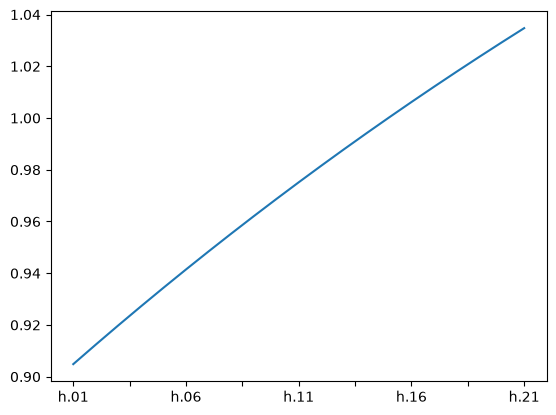

In [228]:
# Use GARCH to forecast variance, I am going to keep everything in variance points for now 
returns = 100 * prices_spx.pct_change().dropna()
model = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
result = model.fit()

forecast = result.forecast(horizon=21)
daily_var_forecast = forecast.variance.iloc[-1]
var_forecast = daily_var_forecast.sum()

-20.39111866824073


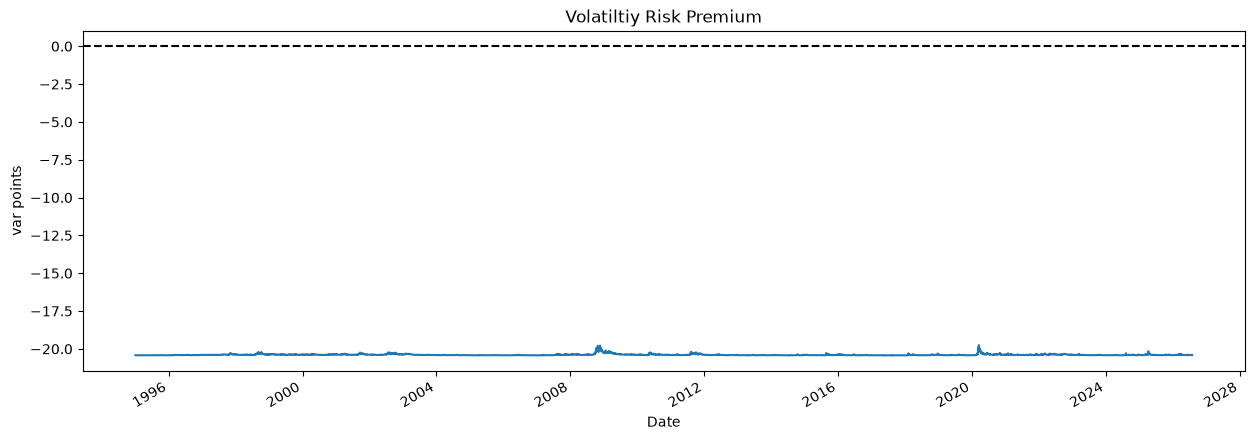

In [229]:
# Now we can define The Volatility Risk Premium
VRP = Kvar - var_forecast
print(VRP.mean())
VRP.plot(title='Volatiltiy Risk Premium',ylabel='var points', figsize=(15,5))
plt.axhline(0, linestyle = "--", color = 'black')

In [230]:
roll_VRP_mean = VRP.expanding(min_periods=252).mean()
roll_VRP_std = VRP.expanding(min_periods=252).std()

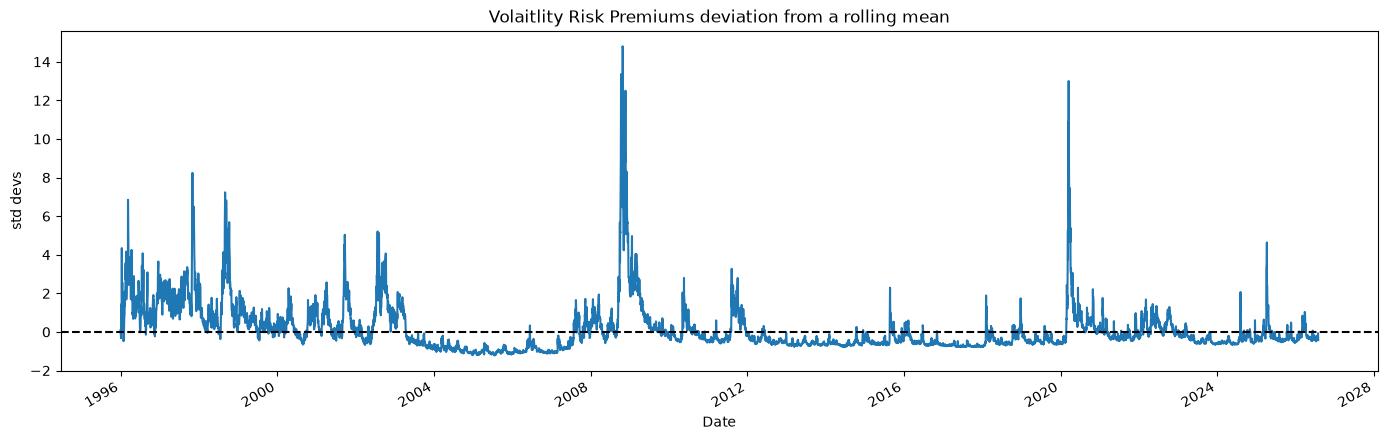

In [231]:
#now can make a z-score, assuming the VRP is mean reverting
VRP_z_score = ((VRP - roll_VRP_mean) / roll_VRP_std).dropna()
VRP_z_score.plot(title='Volaitlity Risk Premiums deviation from a rolling mean', ylabel='std devs', figsize=(17,5))
plt.axhline(0, linestyle = "--", color = 'black')

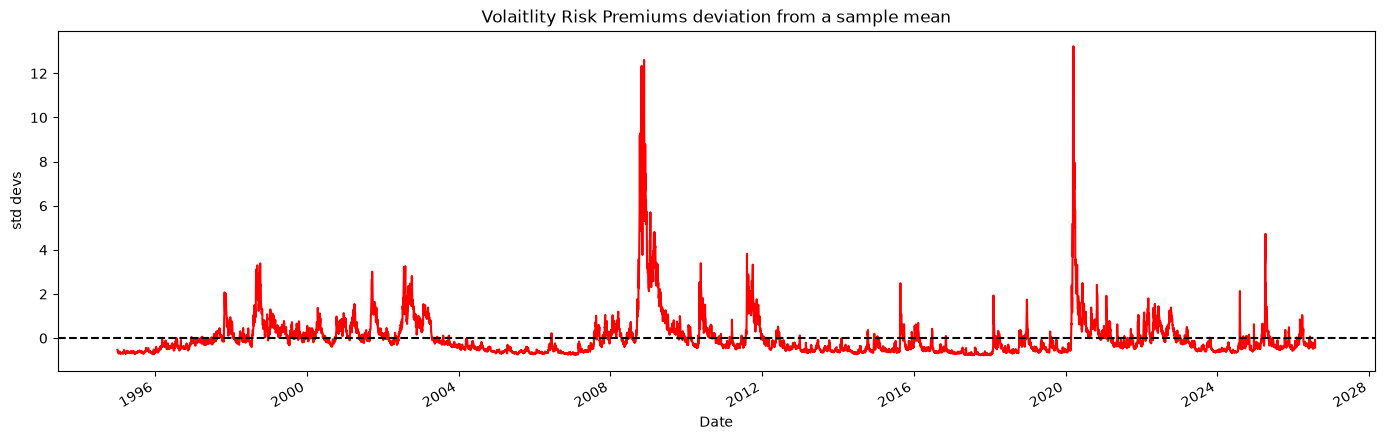

In [232]:
VRP_mean_z_score = ((VRP-VRP.mean())/ VRP.std()).dropna()
VRP_mean_z_score.plot(title='Volaitlity Risk Premiums deviation from a sample mean', ylabel='std devs', color='Red' , figsize=(17,5),)
plt.axhline(0, linestyle = "--", color = 'black')

In [243]:
# Here to show the difference between the in an out of sample data

VRP_IS_z = VRP_z_score[VRP_z_score.index < "2011-01-01"]
print(VRP_IS_z)

Date
1995-12-29    0.093529
1996-01-02   -0.234291
1996-01-03   -0.321773
1996-01-04    1.426576
1996-01-05    1.200148
                ...   
2010-12-27   -0.417662
2010-12-28   -0.427227
2010-12-29   -0.442395
2010-12-30   -0.427097
2010-12-31   -0.412237
Name: ^VIX, Length: 3779, dtype: float64


In [244]:
# Calculate for in sample 
position = 0
positions = [] #  currenlty have an empty book
entry_req = 0.75
Days_in_trade = 0
for z in VRP_IS_z:
    enter_position = 0 
    if position == 0:
        if z > entry_req:
            position = -1
            enter_position = -1
            Days_in_trade = 0
            
        elif z < - entry_req:
            position = 1
            entry_today = 1
            Trading_days = 0
    else:
        Days_in_trade += 1
        if Days_in_trade >= 30:
            position = 0 
            trading_days = 0 
    positions.append(enter_position)

print(len(positions))

3779


In [245]:
positions_series = pd.Series(positions, index= VRP_IS_z.index, name="Position")
Record_of_trades = positions_series[positions_series !=0]
print(len(Record_of_trades))

58


In [246]:
realised_var_30d = {}

for date in Record_of_trades.index:
    location = log_return_daily.index.get_loc(date)
    future_returns = log_return_daily.iloc[location + 1 : location + 1 + window]
    if len(future_returns) == window:
        realised_var_30d[date] = ((future_returns ** 2).sum()* (252 / window))
    else:
        realised_var_30d[date] = np.nan


<Axes: title={'center': 'Short Variance swap Returns In sample'}, xlabel='Date'>

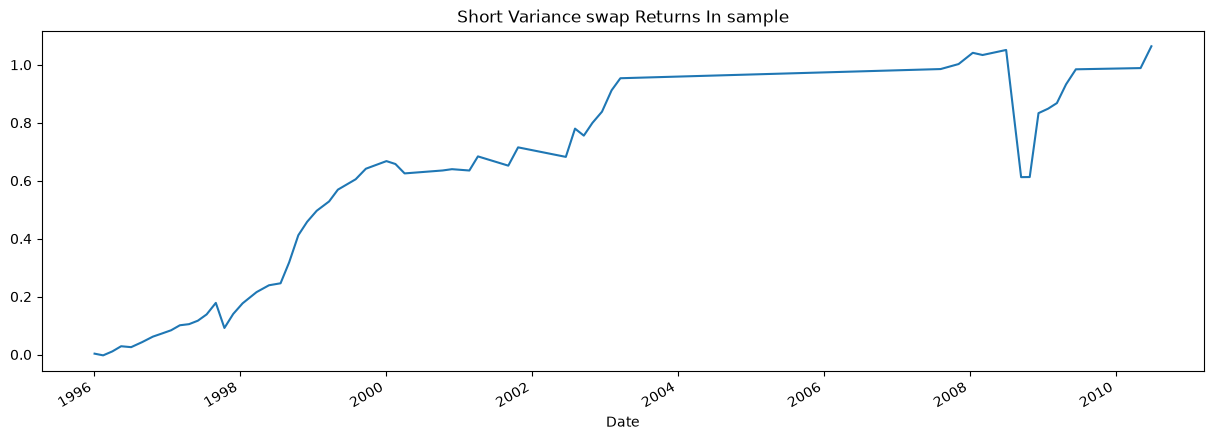

In [247]:
realised_var_30d = pd.Series(realised_var_30d, name="30 day realised variance")

payoff = Record_of_trades * (realised_var_30d - Kvar.loc[Record_of_trades.index])
cumlative_payoff = payoff.cumsum()
cumlative_payoff.plot(title="Short Variance swap Returns In sample",figsize=(15,5))




We can now see below we gain a sharpe ratio of 0.43. However, there is large chance of overfitting. This means the stratergy learns the data rather than really backtesting. Now if you would look at Variance swap backtest Out Of Sample, there is the reulsts for the out of sample testing.  

In [248]:
# sharpe 
mean_payoff = payoff.mean()
std_payoff =  payoff.std()
sharpe_per_payoff = mean_payoff / std_payoff
trades_per_year = len(payoff) / (len(VRP_IS_z)/252)
sharpe_annual = (sharpe_per_payoff * np.sqrt(trades_per_year)) 
print(sharpe_annual)

0.48970409164768375
